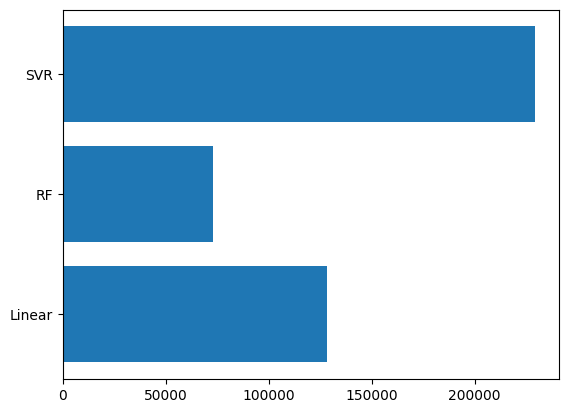

In [1]:

DATA_PATH = "/kaggle/input/datasets/alyelbadry/house-pricing-dataset/house_prices.csv"
import pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

df = pd.read_csv(DATA_PATH).dropna()
X = pd.get_dummies(df.drop("price", axis=1))
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=42)

models = {"Linear":LinearRegression(),"RF":RandomForestRegressor(),"SVR":SVR()}
res=[]
for n,m in models.items():
    m.fit(X_train,y_train)
    res.append([n,mean_absolute_error(y_test,m.predict(X_test))])

table=pd.DataFrame(res,columns=["Model","MAE"])
table.to_csv("RQ2_table.csv",index=False)

plt.figure()
plt.barh(table["Model"],table["MAE"])
plt.savefig("RQ2_figure.pdf")
plt.show()
